<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part2_PyTorch_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔩 Part 2 · PyTorch Advanced Customization
**Topics:**  
Custom Layer/Module · Custom Loss · Custom Metric · Custom Scheduler  
Custom Normalization · Custom Dropout · Custom Training Loop

> **Dataset:** Fashion-MNIST  
> **Framework:** PyTorch  
> **Goal:** Build every training component from scratch using `nn.Module` patterns.


In [1]:
!pip install -q torch torchvision torchmetrics matplotlib pandas scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.5 MB/s eta 0:00:00


In [2]:
import torch, random, os
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 1 · Data Loading

In [3]:
tfm = transforms.Compose([transforms.ToTensor()])

train_full = datasets.FashionMNIST("/tmp/data", train=True, download=True, transform=tfm)
test_ds    = datasets.FashionMNIST("/tmp/data", train=False, download=True, transform=tfm)

train_ds = torch.utils.data.Subset(train_full, range(8000))
val_ds   = torch.utils.data.Subset(train_full, range(8000, 10000))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)
print("Loaders ready.")


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.6MB/s]

Loaders ready.


---
## 2 · Custom Normalization — Group Normalization

In [5]:
class CustomGroupNorm(nn.Module):
    """
    Group Normalization: divide channels into G groups, normalize within each.
    Unlike BatchNorm, performance does NOT degrade at small batch sizes.
    GN with G=1 → LayerNorm; G=C → InstanceNorm.
    """
    def __init__(self, num_channels, num_groups=8, eps=1e-5):
        super().__init__()
        assert num_channels % num_groups == 0, "channels must be divisible by groups"
        self.G   = num_groups
        self.C   = num_channels
        self.eps = eps
        # Learnable scale and shift per channel
        self.gamma = nn.Parameter(torch.ones(1, num_channels, 1, 1))
        self.beta  = nn.Parameter(torch.zeros(1, num_channels, 1, 1))

    def forward(self, x):
        N, C, H, W = x.shape
        # Reshape to (N, G, C//G, H, W)
        x_grouped = x.view(N, self.G, C // self.G, H, W)
        mean = x_grouped.mean(dim=[2,3,4], keepdim=True)
        var  = x_grouped.var( dim=[2,3,4], keepdim=True, unbiased=False)
        x_norm = (x_grouped - mean) / (var + self.eps).sqrt()
        x_norm = x_norm.view(N, C, H, W)
        return self.gamma * x_norm + self.beta

# Sanity check
gn = CustomGroupNorm(64, num_groups=8)
dummy = torch.randn(4, 64, 7, 7)
out = gn(dummy)
print(f"GroupNorm output: {out.shape}   mean≈{out.mean().item():.5f}  std≈{out.std().item():.5f}")

GroupNorm output: torch.Size([4, 64, 7, 7])   mean≈0.00000  std≈1.00003


---
## 3 · Custom Dropout — Spatial Dropout

In [6]:
class SpatialDropout2D(nn.Module):
    """
    Drops entire feature maps (channels) instead of individual activations.
    More effective for CNNs: maintains spatial correlation structure.
    """
    def __init__(self, p=0.2):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0:
            return x
        N, C, H, W = x.shape
        # Create mask over channels only  →  broadcast to all spatial positions
        mask = torch.bernoulli(torch.ones(N, C, 1, 1, device=x.device) * (1 - self.p))
        return x * mask / (1 - self.p)

# Test: verify that whole channels are zeroed
sdrop = SpatialDropout2D(p=0.5)
sdrop.train()
x_test_d = torch.ones(2, 8, 4, 4)
out = sdrop(x_test_d)
# Each channel-map should be either all-ones or all-zeros (scaled)
print("Channel norms:", out[0].view(8,-1).sum(-1).tolist())


Channel norms: [0.0, 0.0, 0.0, 0.0, 32.0, 32.0, 32.0, 32.0]


---
## 4 · Custom Loss — Focal Loss

In [7]:
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al. 2017): down-weights easy examples so the
    model focuses on hard misclassified ones.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha   # per-class weight tensor or None
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: (B, C)  targets: (B,) integer class indices
        log_softmax = F.log_softmax(logits, dim=1)
        softmax     = log_softmax.exp()
        # Gather probability of the correct class
        log_pt = log_softmax.gather(1, targets.unsqueeze(1)).squeeze(1)  # (B,)
        pt     = log_pt.exp()
        focal_weight = (1 - pt) ** self.gamma
        loss = -focal_weight * log_pt
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device).gather(0, targets)
            loss = alpha_t * loss
        return loss.mean() if self.reduction == "mean" else loss.sum()

focal = FocalLoss(gamma=2.0)
logits_test = torch.randn(8, 10)
targets_test = torch.randint(0, 10, (8,))
print("Focal Loss:", focal(logits_test, targets_test).item())


Focal Loss: 2.230088949203491


---
## 5 · Custom Metric — Cohen's Kappa

In [8]:
class CohenKappa:
    """
    Cohen's Kappa: agreement metric that corrects for chance.
    kappa = (p_o - p_e) / (1 - p_e)
    kappa=1 → perfect, kappa=0 → chance, kappa<0 → worse than chance.
    """
    def __init__(self, num_classes):
        self.K = num_classes
        self.reset()

    def reset(self):
        self.conf = torch.zeros(self.K, self.K, dtype=torch.long)

    def update(self, preds, targets):
        preds   = preds.argmax(1).cpu()
        targets = targets.cpu()
        for p, t in zip(preds, targets):
            self.conf[t, p] += 1

    def compute(self):
        N  = self.conf.sum().float()
        po = self.conf.diagonal().sum().float() / N
        row_sums = self.conf.sum(1).float()
        col_sums = self.conf.sum(0).float()
        pe = (row_sums * col_sums).sum() / (N * N)
        kappa = (po - pe) / (1.0 - pe + 1e-8)
        return kappa.item()

print("CohenKappa metric class defined.")


CohenKappa metric class defined.


---
## 6 · Custom Scheduler — Warmup + Cosine Decay

/tmp/ipykernel_508/2152560506.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


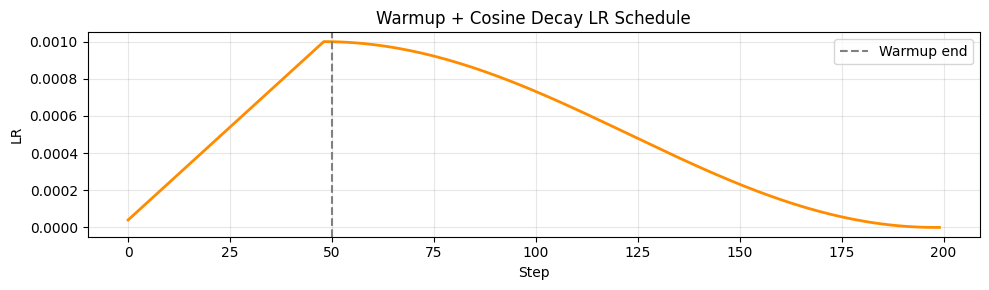

In [9]:
class WarmupCosineScheduler(optim.lr_scheduler.LRScheduler):
    """
    Linear warmup for warmup_steps, then cosine decay to min_lr.
    Standard in Transformers and large-scale vision models.
    """
    def __init__(self, optimizer, warmup_steps, total_steps, min_lr=1e-7, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.min_lr       = min_lr
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        lrs = []
        for base_lr in self.base_lrs:
            if step < self.warmup_steps:
                lr = base_lr * step / max(1, self.warmup_steps)
            else:
                progress = (step - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
                lr = self.min_lr + 0.5 * (base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
            lrs.append(lr)
        return lrs

# Visualise
dummy_opt = optim.Adam([torch.tensor(1.0)], lr=1e-3)
sched = WarmupCosineScheduler(dummy_opt, warmup_steps=50, total_steps=200)
lrs = []
for _ in range(200):
    sched.step()
    lrs.append(sched.get_last_lr()[0])

plt.figure(figsize=(10,3))
plt.plot(lrs, color="darkorange", linewidth=2)
plt.axvline(50, color="gray", linestyle="--", label="Warmup end")
plt.title("Warmup + Cosine Decay LR Schedule")
plt.xlabel("Step"); plt.ylabel("LR"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## 7 · Full Custom Model with All Custom Components

In [10]:
class CustomCNN(nn.Module):
    """
    Integrates: CustomGroupNorm, SpatialDropout2D, custom forward logic.
    """
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            CustomGroupNorm(32, num_groups=8),
            nn.ReLU(),
            SpatialDropout2D(p=0.1),
            nn.MaxPool2d(2),          # 14x14

            nn.Conv2d(32, 64, 3, padding=1),
            CustomGroupNorm(64, num_groups=8),
            nn.ReLU(),
            SpatialDropout2D(p=0.1),
            nn.MaxPool2d(2),          # 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CustomCNN().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 824,650


---
## 8 · Custom Training Loop

In [11]:
EPOCHS  = 12
STEPS   = EPOCHS * len(train_loader)
WU_STEPS= len(train_loader) * 2   # 2-epoch warmup

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = WarmupCosineScheduler(optimizer, warmup_steps=WU_STEPS,
                                   total_steps=STEPS)
criterion = FocalLoss(gamma=2.0)
kappa_met = CohenKappa(num_classes=10)

history = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[],"kappa":[]}

for epoch in range(EPOCHS):
    # ── Train ────────────────────────────────────────────────
    model.train(); t_loss=0; t_correct=0; t_total=0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss   = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        t_loss += loss.item()*len(xb); t_correct += (logits.argmax(1)==yb).sum().item(); t_total += len(xb)

    # ── Validate ─────────────────────────────────────────────
    model.eval(); v_loss=0; v_correct=0; v_total=0
    kappa_met.reset()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            v_loss += criterion(logits, yb).item()*len(xb)
            v_correct += (logits.argmax(1)==yb).sum().item(); v_total += len(xb)
            kappa_met.update(logits, yb)

    history["train_loss"].append(t_loss/t_total); history["train_acc"].append(t_correct/t_total)
    history["val_loss"].append(v_loss/v_total);   history["val_acc"].append(v_correct/v_total)
    history["kappa"].append(kappa_met.compute())
    print(f"E{epoch+1:2d} | train_loss={t_loss/t_total:.4f} acc={t_correct/t_total:.4f} "
          f"| val_loss={v_loss/v_total:.4f} acc={v_correct/v_total:.4f} "
          f"kappa={kappa_met.compute():.4f} "
          f"| lr={scheduler.get_last_lr()[0]:.2e}")


E 1 | train_loss=0.9903 acc=0.5150 | val_loss=0.3120 acc=0.7700 kappa=0.7441 | lr=1.51e-04
E 2 | train_loss=0.3170 acc=0.7746 | val_loss=0.2498 acc=0.8010 kappa=0.7788 | lr=3.00e-04
E 3 | train_loss=0.2444 acc=0.8177 | val_loss=0.1996 acc=0.8450 kappa=0.8277 | lr=2.93e-04
E 4 | train_loss=0.2100 acc=0.8337 | val_loss=0.1794 acc=0.8530 kappa=0.8366 | lr=2.71e-04
E 5 | train_loss=0.1807 acc=0.8535 | val_loss=0.1720 acc=0.8535 kappa=0.8372 | lr=2.38e-04
E 6 | train_loss=0.1578 acc=0.8701 | val_loss=0.1637 acc=0.8545 kappa=0.8382 | lr=1.96e-04
E 7 | train_loss=0.1387 acc=0.8830 | val_loss=0.1516 acc=0.8805 kappa=0.8671 | lr=1.50e-04
E 8 | train_loss=0.1221 acc=0.8935 | val_loss=0.1526 acc=0.8785 kappa=0.8649 | lr=1.03e-04
E 9 | train_loss=0.1088 acc=0.9055 | val_loss=0.1428 acc=0.8865 kappa=0.8738 | lr=6.16e-05
E10 | train_loss=0.1007 acc=0.9094 | val_loss=0.1412 acc=0.8895 kappa=0.8772 | lr=2.85e-05
E11 | train_loss=0.0969 acc=0.9140 | val_loss=0.1387 acc=0.8870 kappa=0.8744 | lr=7.32e-06

## 9 · A/B Comparison

In [12]:
# Baseline: standard BN + CE loss
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*7*7,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self,x): return self.net(x)

base = BaselineCNN().to(DEVICE)
base_opt = optim.Adam(base.parameters(), lr=3e-4)
base_ce  = nn.CrossEntropyLoss()

def quick_train(m, opt, crit, epochs=EPOCHS):
    for _ in range(epochs):
        m.train()
        for xb,yb in train_loader:
            xb,yb = xb.to(DEVICE),yb.to(DEVICE)
            loss = crit(m(xb),yb)
            opt.zero_grad(); loss.backward(); opt.step()

quick_train(base, base_opt, base_ce)

def test_acc_fn(m):
    m.eval(); correct=0; total=0
    with torch.no_grad():
        for xb,yb in test_loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            correct+=(m(xb).argmax(1)==yb).sum().item(); total+=len(xb)
    return correct/total

acc_base   = test_acc_fn(base)
acc_custom = test_acc_fn(model)

df = pd.DataFrame([
    {"Model":"Baseline (BN+CE)",                "Test Acc":round(acc_base,4),  "Custom Components":"None"},
    {"Model":"Custom (GN+Focal+Warmup+Kappa)",  "Test Acc":round(acc_custom,4),"Custom Components":"GroupNorm, SpatialDrop, FocalLoss, WarmupCosine"},
])
print(df.to_string(index=False))


                         Model  Test Acc                               Custom Components
              Baseline (BN+CE)    0.8731                                            None
Custom (GN+Focal+Warmup+Kappa)    0.8810 GroupNorm, SpatialDrop, FocalLoss, WarmupCosine


## 10 · Learning Curves

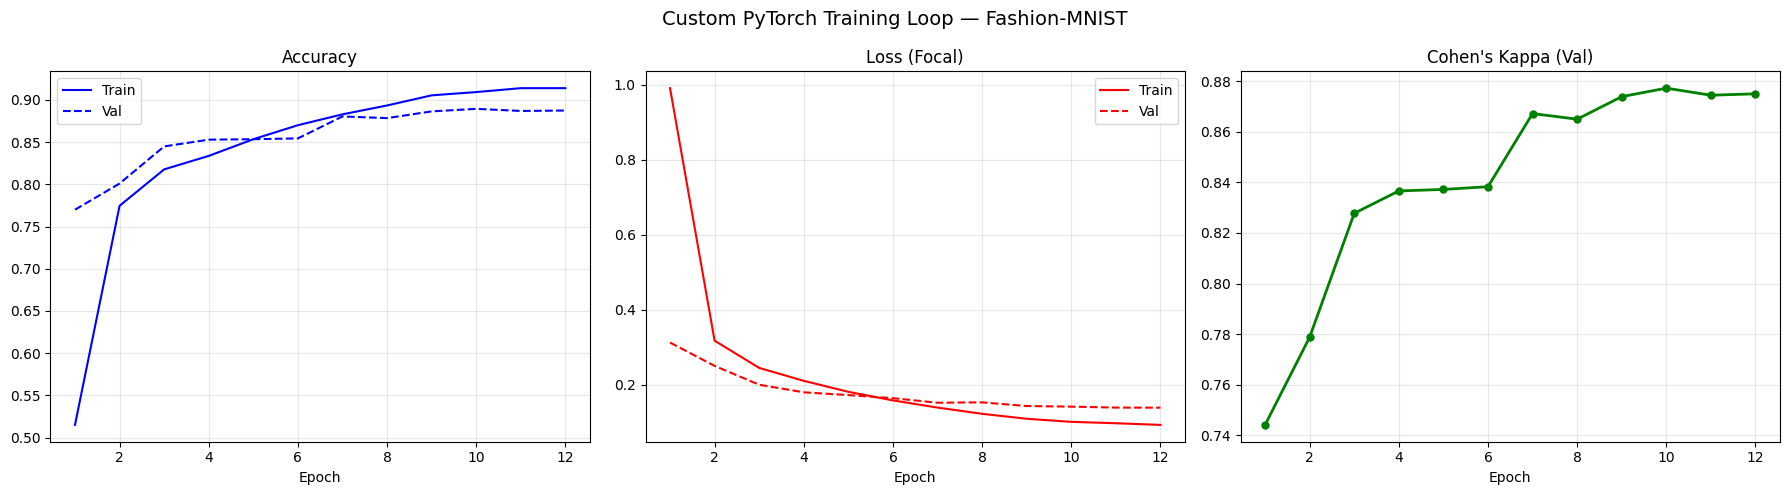

In [13]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
e = range(1,EPOCHS+1)
axes[0].plot(e,history["train_acc"],"b-",label="Train"); axes[0].plot(e,history["val_acc"],"b--",label="Val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(e,history["train_loss"],"r-",label="Train"); axes[1].plot(e,history["val_loss"],"r--",label="Val")
axes[1].set_title("Loss (Focal)"); axes[1].legend()
axes[2].plot(e,history["kappa"],"g-o",linewidth=2,markersize=5)
axes[2].set_title("Cohen's Kappa (Val)")
for ax in axes: ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
plt.suptitle("Custom PyTorch Training Loop — Fashion-MNIST", fontsize=14)
plt.tight_layout(); plt.show()


## 11 · Conclusion

| Custom Component | PyTorch Pattern | Key Benefit |
|---|---|---|
| **GroupNorm** | `nn.Module` with learnable γ,β | Works at small batch sizes |
| **SpatialDropout** | Per-channel Bernoulli mask | Preserves spatial correlations |
| **FocalLoss** | `nn.Module` forward | Hard-example mining without separate sampler |
| **CohenKappa** | Confusion-matrix accumulator | Robust class-imbalance metric |
| **WarmupCosine** | `LRScheduler` subclass | Stable early training + smooth decay |

> All components are `nn.Module`-compatible, device-agnostic, and gradient-safe.
